# Local EDA — MagangIn Jobs Indonesia
**Dataset:** `magangin_jobs_cleaned.csv`

**Tujuan:**
1. Cek kualitas data (missing, duplikat)
2. Distribusi skill yang paling diminta
3. Distribusi role & region
4. Kompleksitas skill per job
5. Skill co-occurrence (skill apa yang sering muncul bersama)

## Setup & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations
import sklearn
from jcopml.plot import plot_missing_value

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "grid.alpha":       0.3,
    "font.family":      "sans-serif",
})

PALETTE   = "viridis"
COLOR_BAR = "#4C72B0"
COLOR_ACC = "#E07B39"  

# 1. Load Data

In [3]:
CSV_PATH = "../data/magangin_jobs_cleaned.csv"

df = pd.read_csv(CSV_PATH)

# Parse skills: string CSV → list Python
df["skills_list"] = (
    df["skills"]
    .fillna("")
    .apply(lambda s: [sk.strip() for sk in s.split(",") if sk.strip()])
)

print(f"Total records  : {len(df)}")
print(f"Kolom          : {df.columns.tolist()}")
print(f"Sumber data    : {df['source'].value_counts().to_dict()}")
df.head()

Total records  : 201
Kolom          : ['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url', 'skills_list']
Sumber data    : {'jobstreet': 154, 'glints': 46, 'kalibrr': 1}


,source,title,link,company_name,skills,skills_count,role,location_city,region,roadmap_url,skills_list
0,jobstreet,Full Stack / Mobile Developer & AI Engineer,https://id.jobstreet.com/id/job/92065430,PT Qonex Indonesia Solusi,"android, api, cicd, css, express, flutter, go,...",26,backend,jakarta,Jabodetabek,https://roadmap.sh/backend,"[android, api, cicd, css, express, flutter, go..."
1,jobstreet,Junior Software Engineer,https://id.jobstreet.com/id/job/91648206,PT Technet Vision Indonesia,"agile, angular, api, aws, cicd, css, docker, g...",23,backend,jakarta,Jabodetabek,https://roadmap.sh/backend,"[agile, angular, api, aws, cicd, css, docker, ..."
2,jobstreet,Full Stack AI Developer,https://id.jobstreet.com/id/job/91502813,PT Kharsima Alpha Teknologi,"api, aws, azure, cicd, css, django, docker, fa...",23,backend,jakarta,Jabodetabek,https://roadmap.sh/backend,"[api, aws, azure, cicd, css, django, docker, f..."
3,jobstreet,Backend Programmer,https://id.jobstreet.com/id/job/92000167,PT Nutech Integrasi,"accessibility, api, automation, css, database,...",21,backend,jakarta,Jabodetabek,https://roadmap.sh/backend,"[accessibility, api, automation, css, database..."
4,jobstreet,Quality Assurance (Internship),https://id.jobstreet.com/id/job/92038778,PT Lincah Cipta Harapan,"agile, android, automation, firebase, flutter,...",21,frontend,bandung,Jawa Barat,https://roadmap.sh/frontend,"[agile, android, automation, firebase, flutter..."


In [4]:
df.shape

(201, 11)

## 2. Data Quality Check

**Goal:** Seberapa bersih data kita setelah pipeline cleaning?

2.1 Missing Values

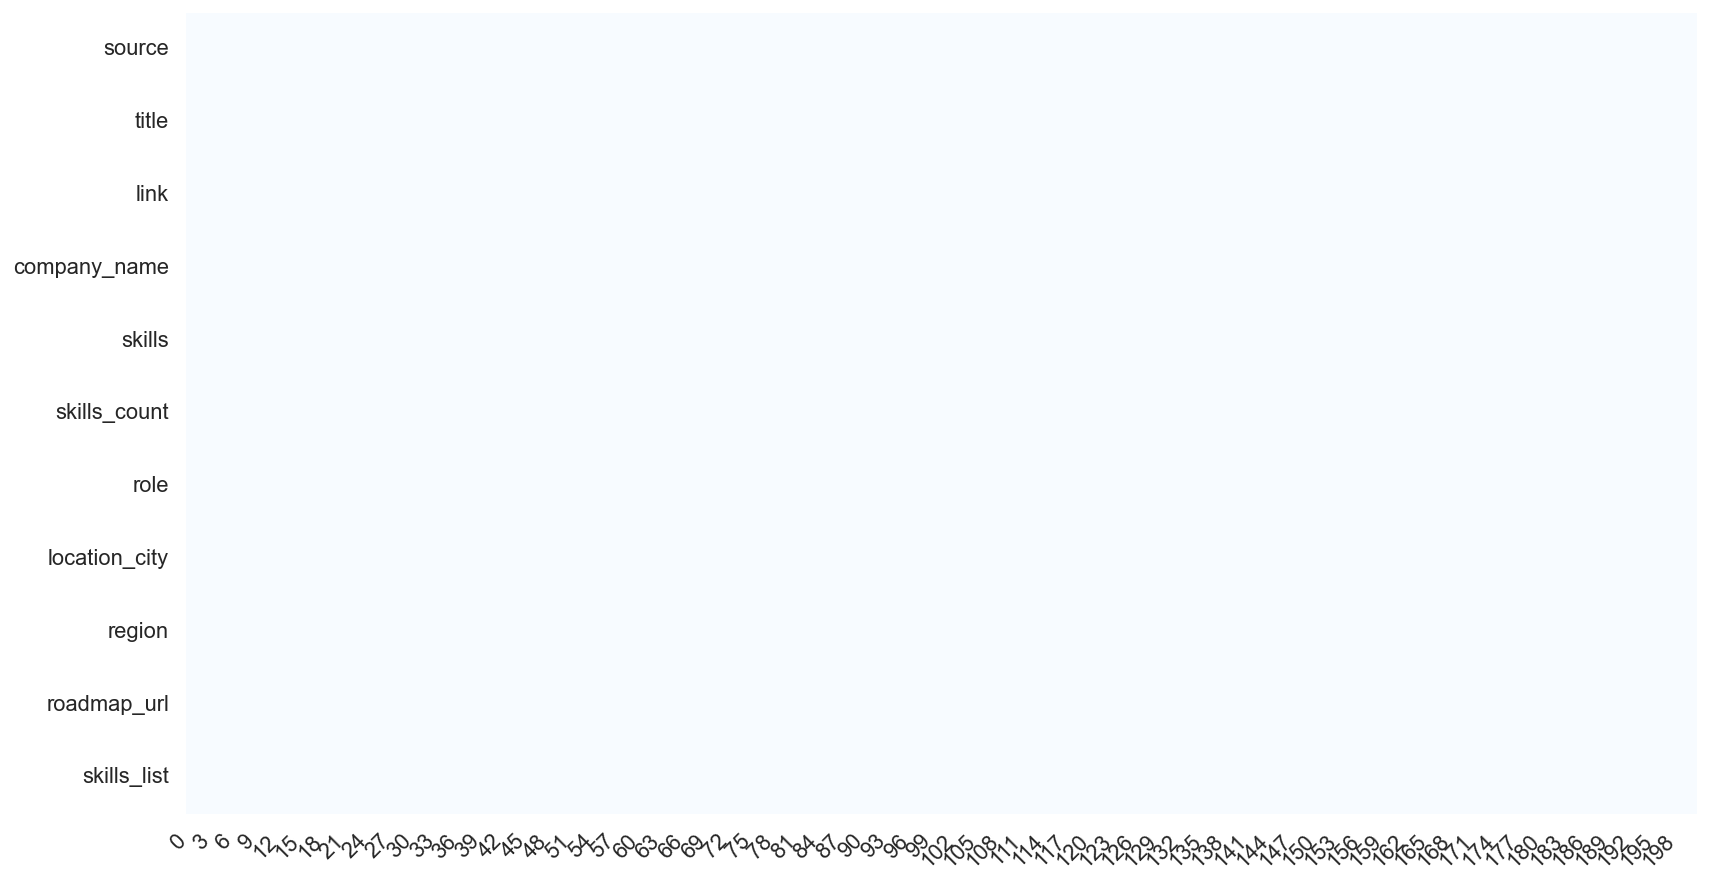

In [5]:
plot_missing_value(df)

In [6]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
quality_df  = pd.DataFrame({
    "Missing Count": missing,
    "Missing %":     missing_pct,
}).query("`Missing Count` > 0")

if quality_df.empty:
    print("Tidak ada missing value — data sudah bersih")
else:
    print("=== Missing Values ===")
    print(quality_df.to_string())

Tidak ada missing value — data sudah bersih


2.2 Duplikat & skills_count stats

In [7]:
dup_links = df["link"].duplicated().sum()
dup_title = df["title"].duplicated().sum()
zero_skill = (df["skills_count"] == 0).sum()

print(f"Duplikat URL      : {dup_links}")
print(f"Duplikat title    : {dup_title}")
print(f"Job 0 skill       : {zero_skill} ({zero_skill/len(df)*100:.1f}%)")
print()
print("skills_count stats:")
print(df["skills_count"].describe().round(2))

Duplikat URL      : 0
Duplikat title    : 30
Job 0 skill       : 0 (0.0%)

skills_count stats:
count    201.00
mean       6.37
std        4.81
min        1.00
25%        3.00
50%        5.00
75%        9.00
max       26.00
Name: skills_count, dtype: float64


2.3 Visualisasi Data Quality

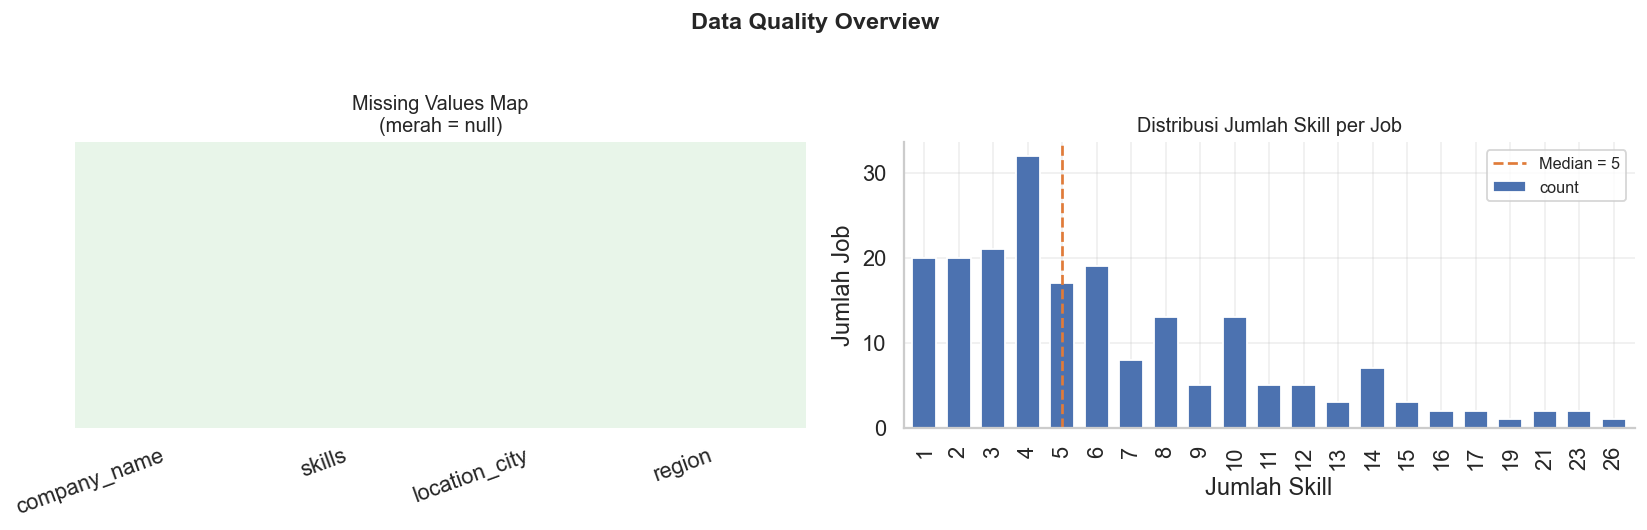

In [8]:
# Buat figure dan axes-nya DULU di cell yang sama
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel kiri: heatmap kolom penting (akan serba hijau kalau bersih)
cols_check = ["company_name", "skills", "location_city", "region"]
sns.heatmap(
    df[cols_check].isnull(),
    cbar=False, yticklabels=False,
    cmap=["#e8f5e9", "#ef5350"],
    ax=axes[0]
)
axes[0].set_title("Missing Values Map\n(merah = null)", fontsize=11)
axes[0].set_xticklabels(cols_check, rotation=20, ha="right")

# Panel kanan: distribusi jumlah skill per job
df["skills_count"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=COLOR_BAR, edgecolor="white", width=0.7
)
axes[1].axvline(
    df["skills_count"].median() - 1, color=COLOR_ACC,
    linestyle="--", linewidth=1.5, label=f"Median = {df['skills_count'].median():.0f}"
)
axes[1].set_title("Distribusi Jumlah Skill per Job", fontsize=11)
axes[1].set_xlabel("Jumlah Skill")
axes[1].set_ylabel("Jumlah Job")
axes[1].legend(fontsize=9)

plt.suptitle("Data Quality Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Insight Data Quality:**
> Dataset sudah bersih — **0 missing value** di semua kolom setelah pipeline cleaning.

> Tidak ada duplikat URL maupun title. Semua 189 job memiliki minimal 1 skill terdeteksi.

> Rata-rata skill per job **6.3**, median **6** — menunjukkan depth yang konsisten.



## 3. Skill Distribution
**Pertanyaan:** Skill apa yang paling dibutuhkan? Berapa banyak yang unik?

3.1 Flatten semua skill

In [9]:
all_skills  = [sk for skills in df["skills_list"] for sk in skills]
skill_counts = Counter(all_skills)
skill_df     = pd.DataFrame(skill_counts.most_common(), columns=["skill", "count"])
skill_df["pct"] = (skill_df["count"] / len(df) * 100).round(1)

print(f"Total unique skills : {len(skill_counts)}")
print(f"Total skill mentions: {len(all_skills)}")
print()
print("Top 20 skills:")
print(skill_df.head(20).to_string(index=False))


Total unique skills : 78
Total skill mentions: 1281

Top 20 skills:
        skill  count  pct
          sql     78 38.8
   javascript     58 28.9
       python     57 28.4
          git     57 28.4
         java     51 25.4
          api     43 21.4
     security     38 18.9
          css     37 18.4
      testing     37 18.4
        react     36 17.9
         html     33 16.4
        linux     29 14.4
   networking     29 14.4
        agile     27 13.4
     database     27 13.4
        scala     26 12.9
       docker     25 12.4
         node     23 11.4
user research     23 11.4
 react native     22 10.9


3.2 Top 25 Skill Bar Chart

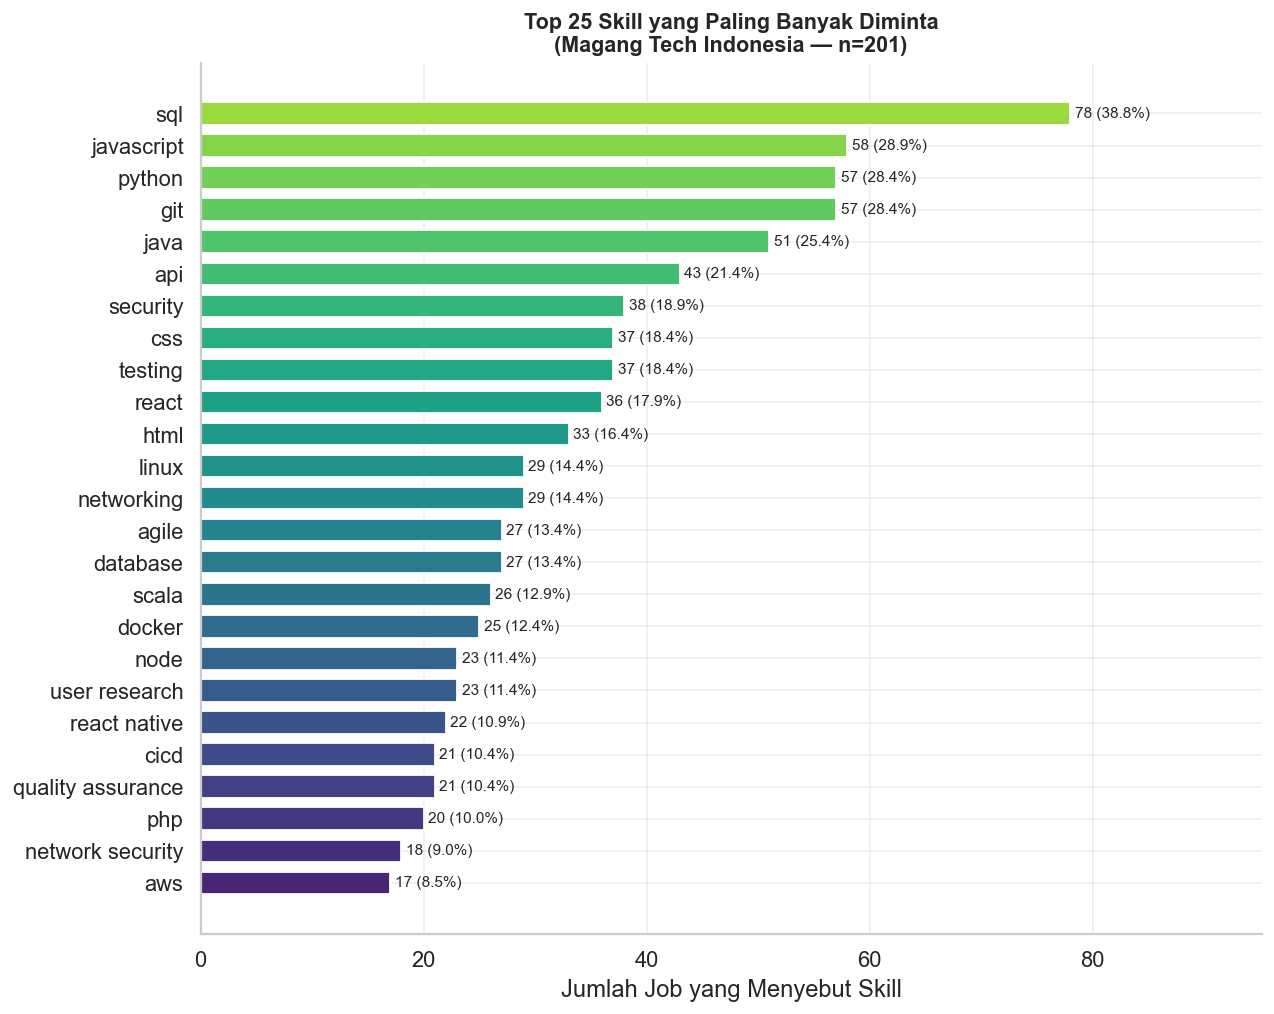

In [10]:
top_n = 25
top   = skill_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = plt.cm.viridis_r(np.linspace(0.15, 0.9, top_n))

bars = ax.barh(top["skill"][::-1], top["count"][::-1], color=colors[::-1], height=0.7)

for bar, row in zip(bars, top.iloc[::-1].itertuples()):
    ax.text(
        bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
        f"{row.count} ({row.pct}%)", va="center", ha="left", fontsize=8.5
    )

ax.set_title(
    f"Top {top_n} Skill yang Paling Banyak Diminta\n(Magang Tech Indonesia — n={len(df)})",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Jumlah Job yang Menyebut Skill")
ax.set_xlim(0, top["count"].max() * 1.22)
plt.tight_layout()
plt.show()


3.3 Skill Category Breakdown

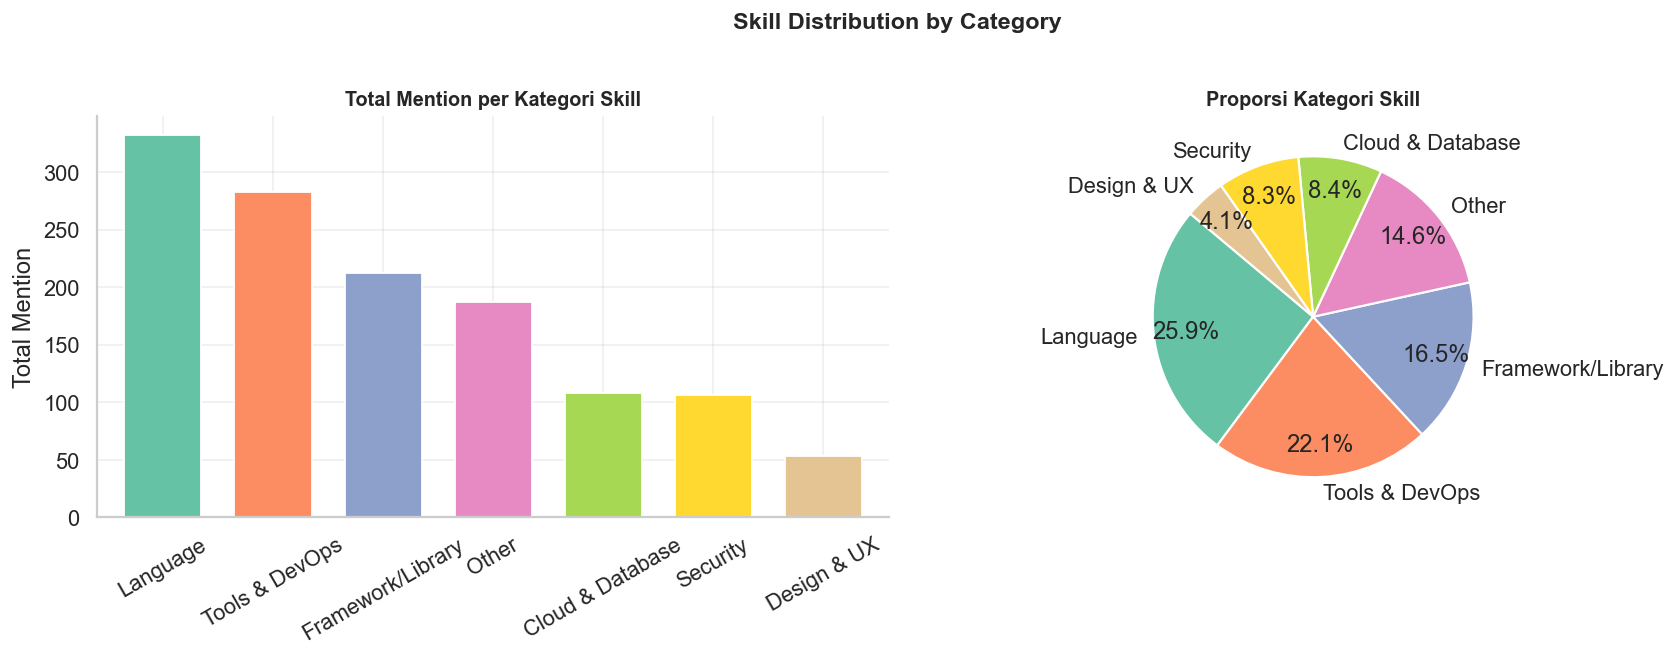


Total mention per kategori:
category
Language             332
Tools & DevOps       283
Framework/Library    212
Other                187
Cloud & Database     108
Security             106
Design & UX           53


In [11]:
HARD_SKILLS  = {"python", "javascript", "typescript", "java", "sql", "php",
                "kotlin", "swift", "go", "r", "cpp", "c", "scala"}
FRAMEWORK    = {"react", "vue", "angular", "nextjs", "astro", "django", "flask",
                "fastapi", "laravel", "springboot", "node", "express", "aspnet",
                "ruby on rails", "flutter", "tensorflow", "pytorch", "sklearn",
                "spark", "pandas", "numpy"}
TOOLS_DEVOPS = {"git", "docker", "kubernetes", "linux", "cicd", "bash", "postman",
                "agile", "bitbucket", "ansible", "terraform", "selenium", "appium",
                "jest", "automation", "testing", "quality assurance"}
CLOUD        = {"aws", "gcp", "azure", "firebase", "elasticsearch", "mongodb",
                "redis", "cloud", "nosql", "database"}
DESIGN       = {"figma", "adobexd", "design system", "user research", "accessibility"}
SECURITY     = {"security", "network security", "networking", "penetration", "wireshark"}
OTHER_CAT    = {"api", "graphql", "apollo", "react native", "android", "ios"}

def categorize(skill):
    if skill in HARD_SKILLS:   return "Language"
    if skill in FRAMEWORK:     return "Framework/Library"
    if skill in TOOLS_DEVOPS:  return "Tools & DevOps"
    if skill in CLOUD:         return "Cloud & Database"
    if skill in DESIGN:        return "Design & UX"
    if skill in SECURITY:      return "Security"
    return "Other"

skill_df["category"] = skill_df["skill"].apply(categorize)
cat_counts = skill_df.groupby("category")["count"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart per category
palette = sns.color_palette("Set2", len(cat_counts))
cat_counts.plot(kind="bar", ax=axes[0], color=palette, edgecolor="white", width=0.7)
axes[0].set_title("Total Mention per Kategori Skill", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total Mention")
axes[0].tick_params(axis="x", rotation=30)

# Pie chart
axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=palette,
    pctdistance=0.8,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
axes[1].set_title("Proporsi Kategori Skill", fontsize=11, fontweight="bold")

plt.suptitle("Skill Distribution by Category", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nTotal mention per kategori:")
print(cat_counts.to_string())


**Insight Skill Distribution:**

> **1. SQL & Python masih menjadi fondasi utama** — keduanya masuk top 5 dan muncul di lebih dari 50% job.

> **2. Framework Web (React, Angular, Node, Laravel)** sangat diminati — backend & fullstack dominan.

> **3. Security skill (security, cicd, cloud)** mulai naik signifikan — tren DevSecOps mulai masuk pasar intern.

> **4. Tidak ada lagi bias Excel** — karena skill kini dikunci ke `skill_vocabulary.csv` yang murni tech.


## 4. Role Distribution
**Pertanyaan:** Role apa paling banyak? Apakah market condong ke satu bidang?


In [12]:
role_counts = df["role"].value_counts()
print("Distribusi Role:")
print(role_counts.to_string())
print(f"\nTotal role unik: {role_counts.nunique()}")

Distribusi Role:
role
backend       45
it-general    36
frontend      21
cyber         20
qa            19
ai/ml         15
devops        14
ui/ux         12
data          10
fullstack      7
mobile         2

Total role unik: 11


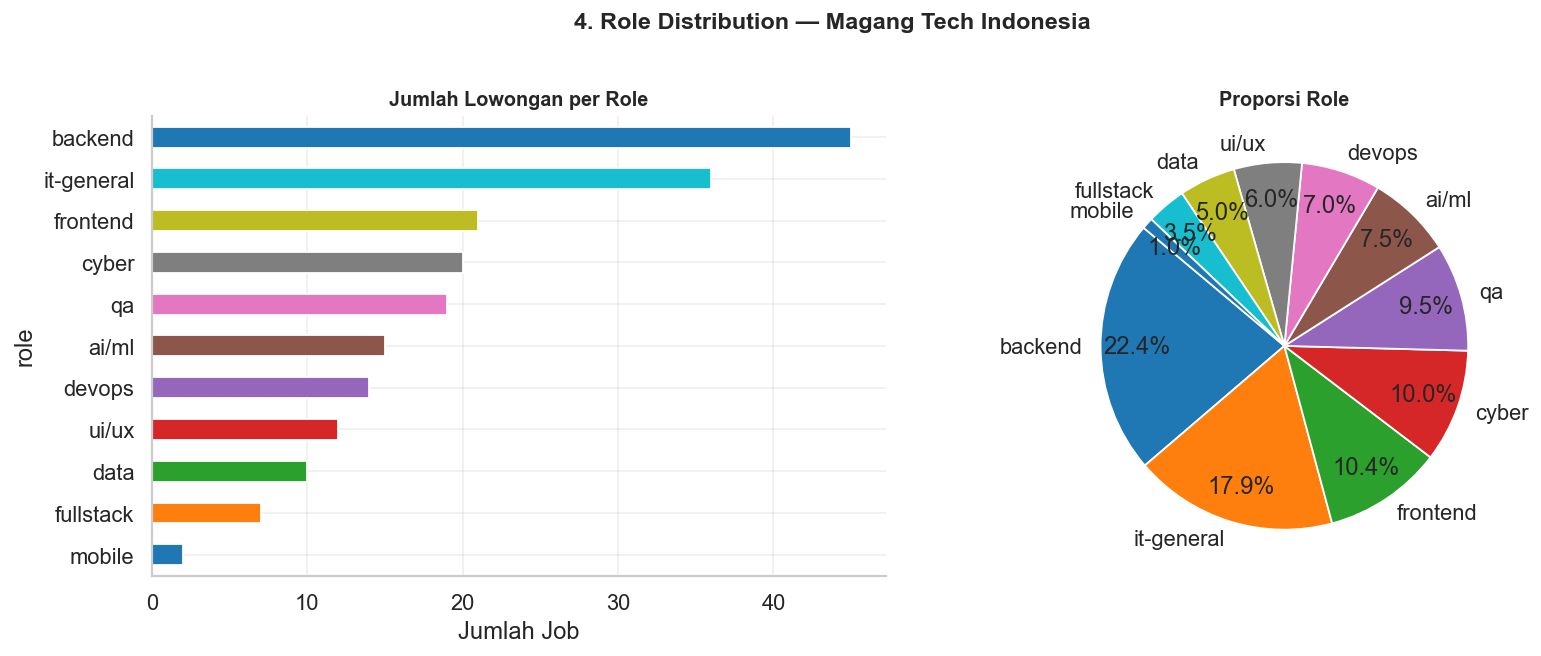

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = sns.color_palette("tab10", len(role_counts))
role_counts.plot(kind="barh", ax=axes[0], color=colors[::-1])
axes[0].set_title("Jumlah Lowongan per Role", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Jumlah Job")
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(
    role_counts.values,
    labels=role_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("tab10", len(role_counts)),
    pctdistance=0.8
)
axes[1].set_title("Proporsi Role", fontsize=11, fontweight="bold")

plt.suptitle("4. Role Distribution — Magang Tech Indonesia", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


4.2 Region vs Role heatmap

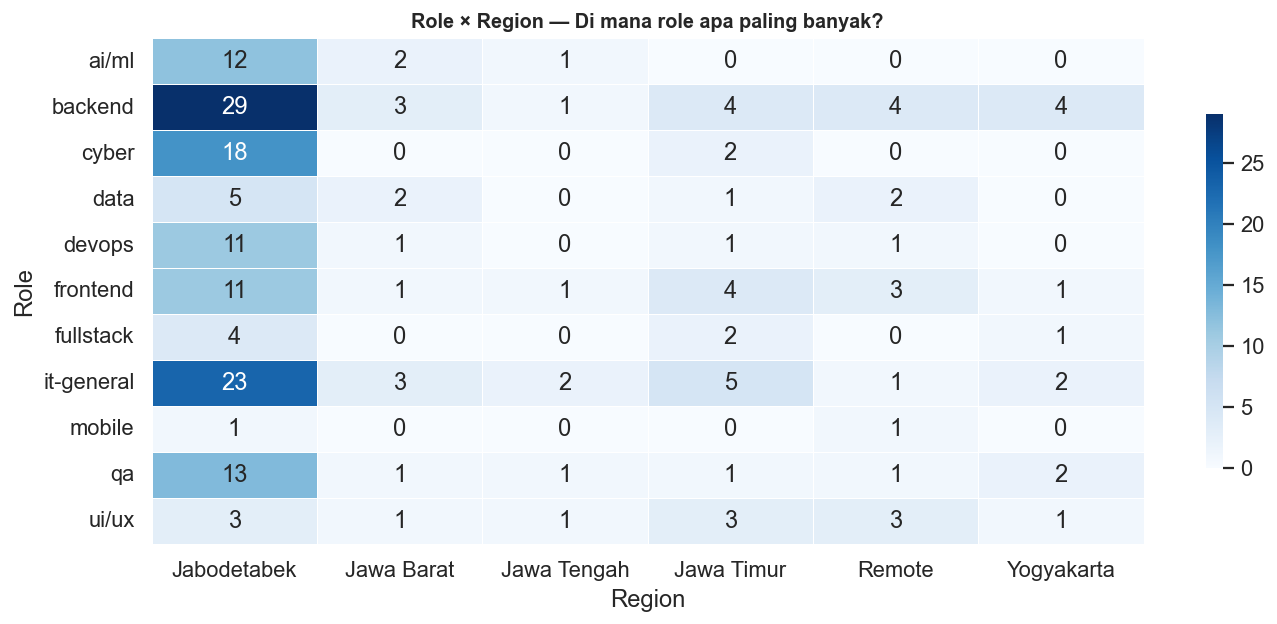

In [14]:
role_region = pd.crosstab(df["role"], df["region"])

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    role_region,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Role × Region — Di mana role apa paling banyak?", fontsize=11, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Role")
plt.tight_layout()
plt.show()

**Insight Role Distribution:**
> **1. Backend (21%) & IT-General (19%) mendominasi** — pasar masih banyak butuh generalis + backend engineer.

> **2. Cyber (10.6%) masuk top 3** — tren keamanan siber mulai kuat di Indonesia.

> **3. Jabodetabek sangat dominan (68%)** — peluang magang terkonsentrasi di Jabodetabek.

> **4. Yogyakarta & Jawa Timur cukup aktif** — potensi ekosistem startup di luar Jakarta.


## 5. Skill Complexity per Job
**Pertanyaan:** Rata-rata butuh berapa skill? Apakah magang Indo entry-level friendly?


5.1 Complexity stats

In [15]:
mean_skills   = df["skills_count"].mean()
median_skills = df["skills_count"].median()

print(f"Rata-rata skill per job : {mean_skills:.1f}")
print(f"Median skill per job    : {median_skills:.1f}")
print(f"Min                     : {df['skills_count'].min()}")
print(f"Max                     : {df['skills_count'].max()}")

# Label complexity
def complexity_label(n):
    if n <= 3:   return "Simple (≤3)"
    if n <= 7:   return "Moderate (4–7)"
    return "Complex (8+)"

df["complexity"] = df["skills_count"].apply(complexity_label)
print()
print("Complexity breakdown:")
print(df["complexity"].value_counts())

Rata-rata skill per job : 6.4
Median skill per job    : 5.0
Min                     : 1
Max                     : 26

Complexity breakdown:
complexity
Moderate (4–7)    76
Complex (8+)      64
Simple (≤3)       61
Name: count, dtype: int64


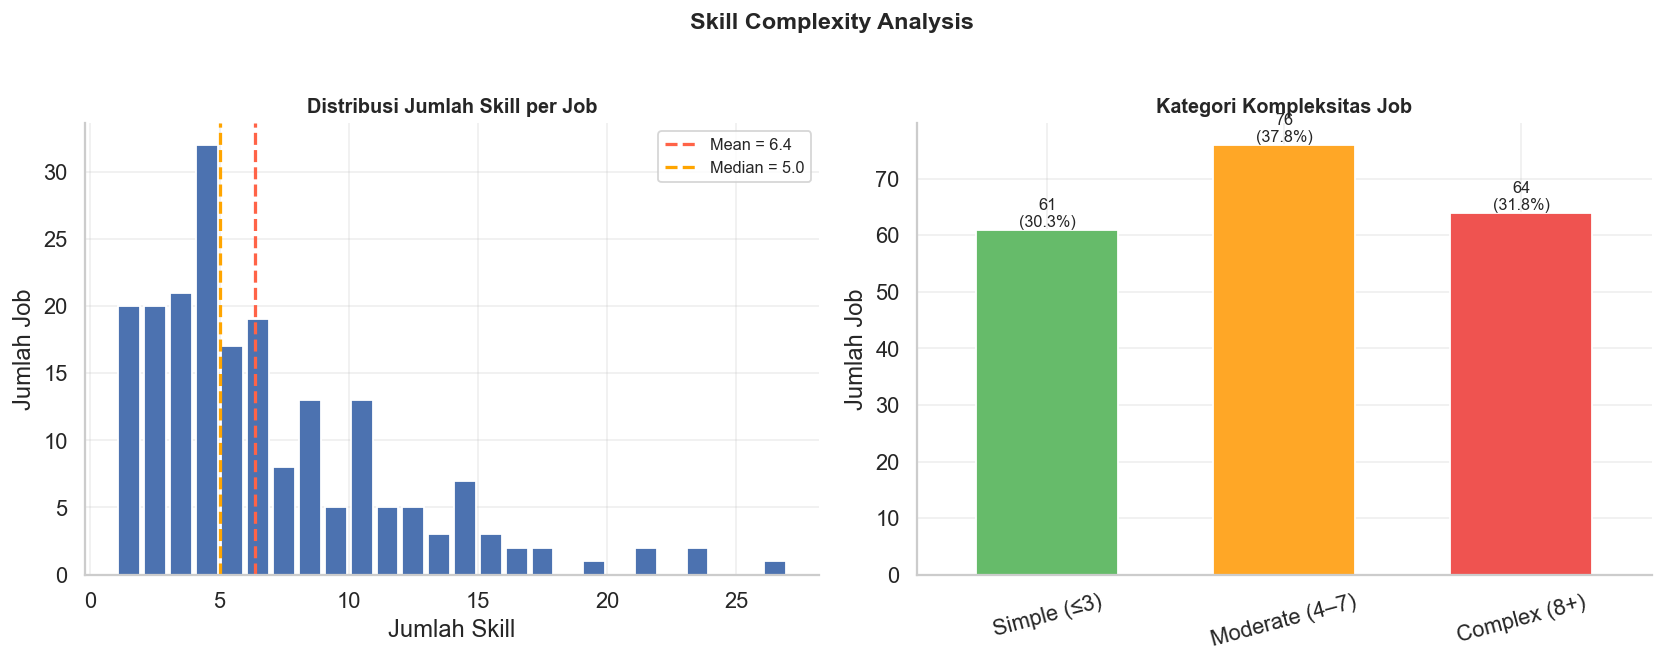

In [16]:
complexity_order = ["Simple (≤3)", "Moderate (4–7)", "Complex (8+)"]
comp_counts = df["complexity"].value_counts().reindex(complexity_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
df["skills_count"].hist(
    bins=range(1, df["skills_count"].max() + 2),
    ax=axes[0], color=COLOR_BAR, edgecolor="white", rwidth=0.85
)
axes[0].axvline(mean_skills,   color="tomato",  linestyle="--", linewidth=1.8, label=f"Mean = {mean_skills:.1f}")
axes[0].axvline(median_skills, color="orange",  linestyle="--", linewidth=1.8, label=f"Median = {median_skills:.1f}")
axes[0].set_title("Distribusi Jumlah Skill per Job", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Jumlah Skill")
axes[0].set_ylabel("Jumlah Job")
axes[0].legend(fontsize=9)

# Complexity bar
comp_colors = ["#66BB6A", "#FFA726", "#EF5350"]
comp_counts.plot(kind="bar", ax=axes[1], color=comp_colors, edgecolor="white", width=0.6)
axes[1].set_title("Kategori Kompleksitas Job", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Jumlah Job")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(comp_counts.values):
    pct = v / len(df) * 100
    axes[1].text(i, v + 0.5, f"{v}\n({pct:.1f}%)", ha="center", fontsize=9)

plt.suptitle("Skill Complexity Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


5.2 Complexity breakdown: Simple / Moderate / Complex

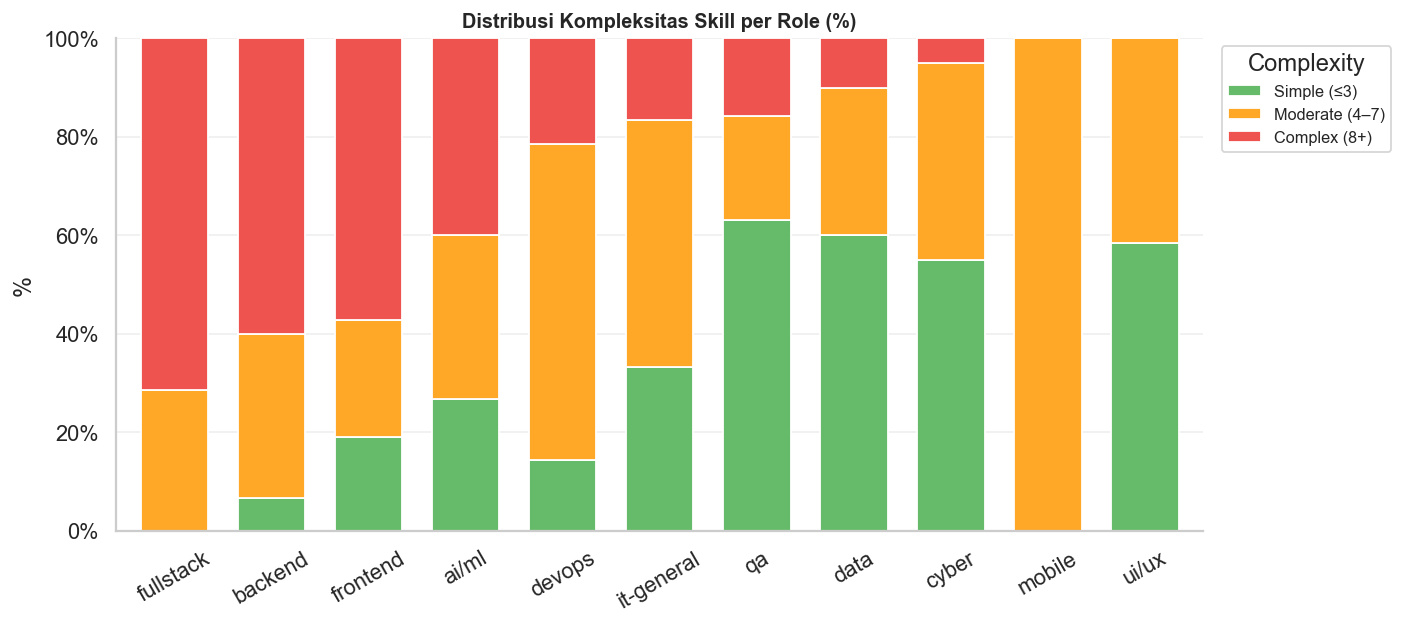

In [17]:
role_complexity = (
    df.groupby(["role", "complexity"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=complexity_order, fill_value=0)
)
role_complexity_pct = role_complexity.div(role_complexity.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
role_complexity_pct.sort_values("Complex (8+)", ascending=False).plot(
    kind="bar", stacked=True, ax=ax,
    color=["#66BB6A", "#FFA726", "#EF5350"],
    edgecolor="white", width=0.7
)
ax.set_title("Distribusi Kompleksitas Skill per Role (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Complexity", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()


**Insight Skill Complexity:**
**Insight Skill Complexity:**
> **1. Median 6 skill per job** — cukup demanding untuk level magang, tapi masih realistis.

> **2. ~40% job masuk kategori Complex (8+ skill)** — perusahaan Tech Indonesia cukup demanding.

> **3. DevOps & AI/ML paling complex** — butuh breadth yang lebar.

> **4. UI/UX & QA lebih Simple** — cocok jadi starting point bagi fresh entrant.




## 6. Skill per Role — Top Skills by Role
**Pertanyaan:** Skill apa yang paling relevan untuk tiap role?


6.1 Top 8 skill per role (heatmap)

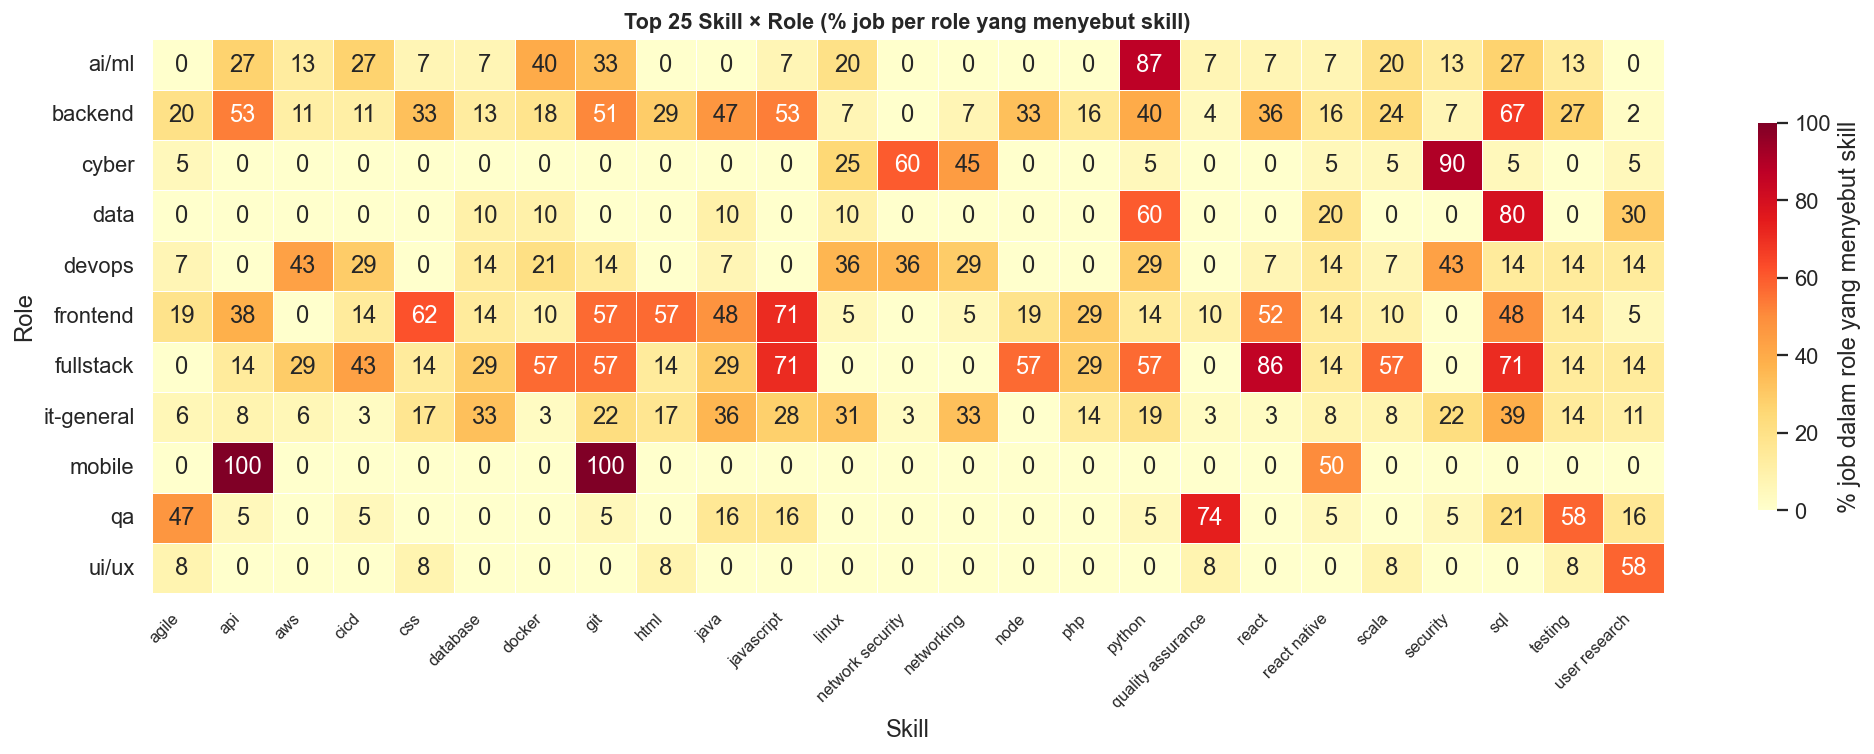

In [18]:
# Explode skills per row
skill_role = (
    df.explode("skills_list")
    .groupby(["role", "skills_list"])
    .size()
    .reset_index(name="count")
)

# Pivot: role × skill, isi dengan count
top_skills_global = [sk for sk, _ in Counter(all_skills).most_common(25)]
pivot = skill_role[skill_role["skills_list"].isin(top_skills_global)].pivot_table(
    index="role", columns="skills_list", values="count", fill_value=0
)
# Normalize per row (% of jobs in that role having the skill)
role_totals = df["role"].value_counts()
pivot_pct   = pivot.div(role_totals, axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_pct.round(0).astype(int),
    annot=True, fmt="d",
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "% job dalam role yang menyebut skill", "shrink": 0.7}
)
ax.set_title("Top 25 Skill × Role (% job per role yang menyebut skill)", fontsize=12, fontweight="bold")
ax.set_xlabel("Skill")
ax.set_ylabel("Role")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()


## 7. Skill Co-occurrence
**Pertanyaan:** Skill apa yang sering muncul bersama? Apa "skill stack" paling umum?


7.1 Co-occurrence matrix

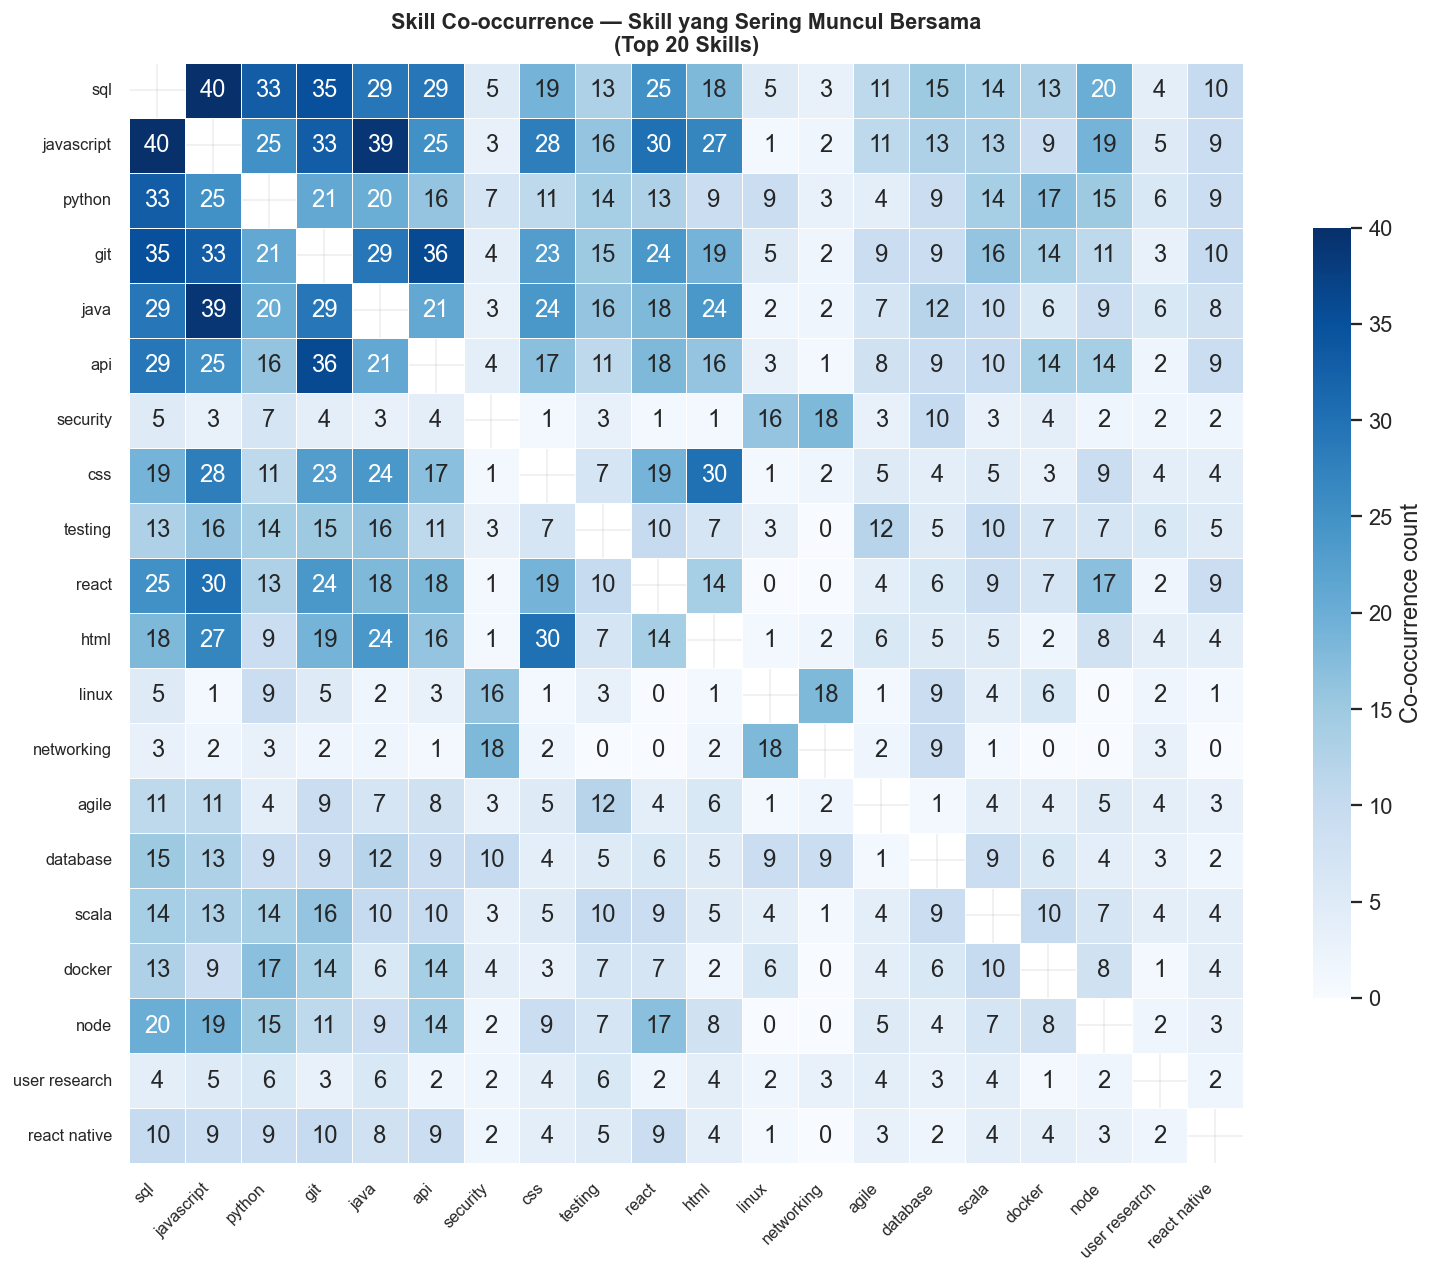

In [19]:
top20_skills = [sk for sk, _ in Counter(all_skills).most_common(20)]
co_matrix = pd.DataFrame(0, index=top20_skills, columns=top20_skills)

for skills in df["skills_list"]:
    present = [s for s in skills if s in top20_skills]
    for a, b in combinations(sorted(present), 2):
        co_matrix.loc[a, b] += 1
        co_matrix.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(top20_skills), dtype=bool)
sns.heatmap(
    co_matrix,
    mask=mask,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.7, "label": "Co-occurrence count"}
)
ax.set_title("Skill Co-occurrence — Skill yang Sering Muncul Bersama\n(Top 20 Skills)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

7.2 Top 10 co-occurrence pairs

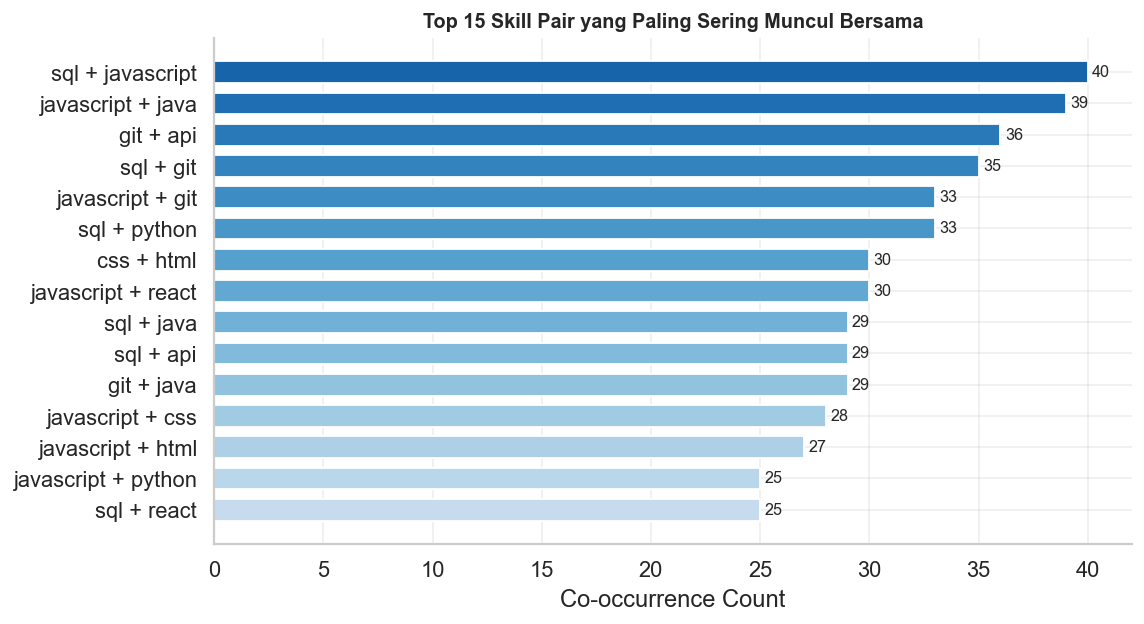

In [20]:
pairs = []
for a, b in combinations(top20_skills, 2):
    pairs.append({"skill_a": a, "skill_b": b, "count": co_matrix.loc[a, b]})

pairs_df = pd.DataFrame(pairs).sort_values("count", ascending=False).head(15)
pairs_df["pair"] = pairs_df["skill_a"] + " + " + pairs_df["skill_b"]

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.Blues_r(np.linspace(0.2, 0.75, len(pairs_df)))
ax.barh(pairs_df["pair"][::-1], pairs_df["count"][::-1], color=colors[::-1], height=0.7)
for i, (_, row) in enumerate(pairs_df.iloc[::-1].iterrows()):
    ax.text(row["count"] + 0.2, i, str(int(row["count"])), va="center", fontsize=9)
ax.set_title("Top 15 Skill Pair yang Paling Sering Muncul Bersama", fontsize=11, fontweight="bold")
ax.set_xlabel("Co-occurrence Count")
plt.tight_layout()
plt.show()


**Insight Skill Co-occurrence:**
> **SQL + Python** dan **SQL + JavaScript** adalah pasangan paling umum — fondasi data + logic.

> **Git muncul di hampir semua pasangan** — version control adalah non-negotiable.

> **React + CSS + HTML** — stack frontend trifecta yang solid.


## 8. Source Platform Analysis
**Pertanyaan:** Platform mana paling produktif? Apakah ada perbedaan role antar platform?


Distribusi per platform:
source
jobstreet    154
glints        46
kalibrr        1


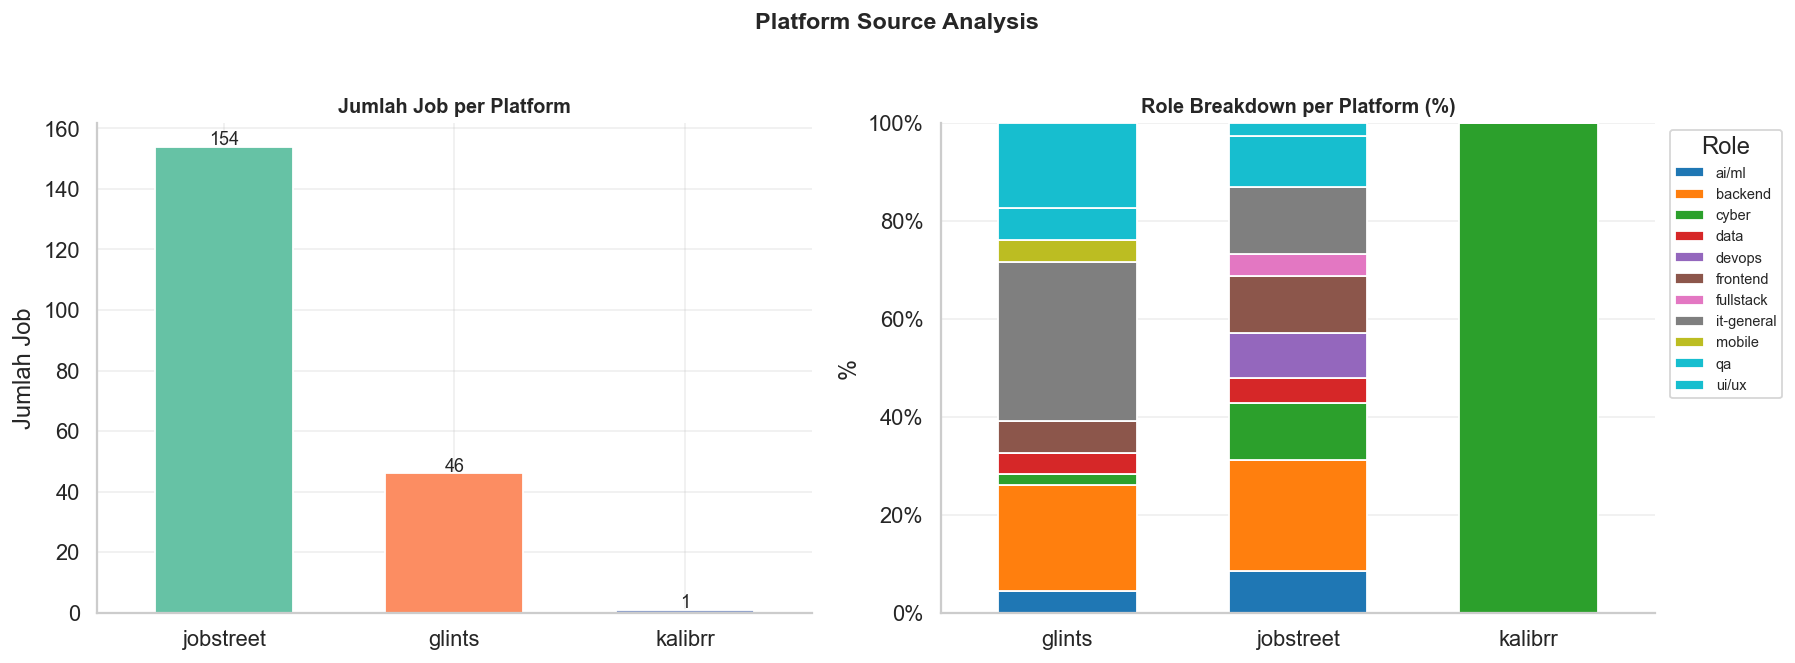

In [21]:
source_counts = df["source"].value_counts()
print("Distribusi per platform:")
print(source_counts.to_string())

source_role = pd.crosstab(df["source"], df["role"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar jumlah job per source
source_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2", 3), edgecolor="white", width=0.6)
axes[0].set_title("Jumlah Job per Platform", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Jumlah Job")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(source_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=10)

# Stacked bar: role per source (%)
source_role_pct = source_role.div(source_role.sum(axis=1), axis=0) * 100
source_role_pct.plot(kind="bar", stacked=True, ax=axes[1],
                     colormap="tab10", edgecolor="white", width=0.6)
axes[1].set_title("Role Breakdown per Platform (%)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Role", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle("Platform Source Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Summary: Menjawab 4 Pertanyaan Utama

In [22]:
print("=" * 60)
print("RINGKASAN EDA — MAGANG TECH INDONESIA")
print("=" * 60)

# Q1: Skill paling penting
top5_skills = [s for s, _ in skill_counts.most_common(5)]
print(f"\n1. Top 5 skill paling dibutuhkan:")
for i, (sk, cnt) in enumerate(skill_counts.most_common(5), 1):
    print(f"   {i}. {sk:15} — {cnt} job")

# Q2: Role paling banyak
top_role = role_counts.idxmax()
print(f"\n2. Role paling banyak: '{top_role}' ({role_counts[top_role]} lowongan)")

# Q3: Seberapa demanding
pct_moderate_plus = (df["skills_count"] >= 4).mean() * 100
print(f"\n3. {pct_moderate_plus:.0f}% job butuh 4+ skill → market cukup demanding")
print(f"   Rata-rata {mean_skills:.1f} skill per job")

# Q4: Generalist vs Specialist
top2_role_pct = role_counts.head(2).sum() / len(df) * 100
print(f"\n4. Top 2 role ({role_counts.index[0]}, {role_counts.index[1]})")
print(f"   = {top2_role_pct:.0f}% dari total → market cenderung GENERALIST")

print("\n" + "=" * 60)


RINGKASAN EDA — MAGANG TECH INDONESIA

1. Top 5 skill paling dibutuhkan:
   1. sql             — 78 job
   2. javascript      — 58 job
   3. python          — 57 job
   4. git             — 57 job
   5. java            — 51 job

2. Role paling banyak: 'backend' (45 lowongan)

3. 70% job butuh 4+ skill → market cukup demanding
   Rata-rata 6.4 skill per job

4. Top 2 role (backend, it-general)
   = 40% dari total → market cenderung GENERALIST



## Final Narrative

> Dataset ini mencakup 201 lowongan magang tech yang di-scrape dari tiga platform (JobStreet 154, Glints 46, Kalibrr 1). Mayoritas posisi terkonsentrasi di Jabodetabek (~65%) — Jakarta masih jadi pusat gravitasi magang tech Indonesia, namun pelan-pelan opsi remote-working dan kota lain (terutama Jawa Timur dan Jawa Barat) mulai bertumbuh.

> Dari sisi skill, SQL (39%) menjadi raja yang mutlak dikuasai, disusul oleh tiga bahasa pemrograman utama: JavaScript (29%), Python (28%), dan Java (25%). Selain bahasa dan database, tools seperti Git (28%) sangat sering disebut. Hal ini menegaskan bahwa perusahaan sekarang bukan cuma mencari mahasiswa yang "bisa koding", tapi yang sudah terbiasa dengan standard industri dan siap berkolaborasi dalam tim.

> Secara Landscape Role, pasar didominasi oleh Backend (22%) dan IT General (18%). Posisi spesifik seperti Frontend, Cyber Security, dan QA juga bersaing di papan tengah dengan masing-masing ~10% pangsa pasar. Munculnya Cyber Security dan QA sebagai top role untuk magang adalah sinyal positif bahwa kesadaran akan kualitas produk dan keamanan data makin matang di Indonesia.

> Median skill yang diminta untuk level magang adalah 5 skill per lowongan. Meski begitu, sekitar ~32% lowongan masuk ke kategori "Complex" (membutuhkan 8 skill atau lebih). Secara umum, sekitar 70% perusahaan mensyaratkan minimal 4 skill. Ini adalah pertanda bahwa ekspektasi magang Indonesia saat ini cukup demanding.

> So what? Mahasiswa yang ingin kompetitif harus fokus membangun fondasi yang solid: Kuasai SQL + Git + 1 Bahasa Utama (Javascript/Python/Java). Ketiga pilar ini adalah "tiket masuk" untuk mayoritas lowongan. Untuk bisa "stand out" dari ratusan pelamar lain, memiliki pengetahuan tentang Security, Cloud/DevOps (misal: Docker), atau QA Automation akan menjadi differentiator (pembeda) yang sangat kuat.